In [24]:
# ============================================================
# INSTALL DEPENDENCIES (Optional)
# ============================================================
# !pip install pandas numpy matplotlib seaborn

# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [25]:
# ============================================================
# CELL 3 — DATASET PATH
# ============================================================

DATASET_PATH = "../parquet_exports/gold_ticket_similarity.parquet"

print("Dataset path:", DATASET_PATH)


Dataset path: ../parquet_exports/gold_ticket_similarity.parquet


In [26]:
# ============================================================
# CELL 4 — LOAD DATASET
# ============================================================
df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()


DATASET LOADED
Rows    : 230,114
Columns : 29


,similarity_pk,ticket_pk,source_system,ticket_id,created_at,closed_at,text_corpus,synthetic_text_corpus,similarity_method,embedding_strategy,text_source_type,embedding_model,priority_encoded,urgency_encoded,impact_encoded,followup_count_bucket,corpus_quality_score,similarity_confidence,followup_count,avg_followup_content_length,private_followup_ratio,url_content_ratio,meaningful_content_ratio,has_os_context,has_hardware_context,has_bios_context,has_software_context,similar_ticket_ids,similarity_scores
0,4ceef0c770bdc93599fb1d7131032c69,2013_2,GLPI,2,2013-05-13 17:27:43,2013-05-16 12:29:40,NaN,prio_high urg_critical impact_medium ticket_un...,synthetic_context,structured_metadata,synthetic_context,NaN,4.0,5.0,3.0,2.0,0.3,0.25,3,271.00,0.0,0.0,1.0,0,0,0,0,None,None
1,6cc7ce0f8b7df1ecd0560860283acf40,2013_3,GLPI,3,2013-05-14 17:38:55,2013-06-30 10:55:47,NaN,prio_medium urg_medium impact_medium ticket_un...,synthetic_context,structured_metadata,synthetic_context,NaN,3.0,3.0,3.0,2.0,0.3,0.25,3,127.00,0.0,0.0,1.0,0,0,0,0,None,None
2,23142610733bcac6466bce80d180c346,2013_4,GLPI,4,2013-05-15 13:01:00,2013-07-01 19:46:26,NaN,prio_medium urg_medium impact_medium ticket_un...,synthetic_context,structured_metadata,synthetic_context,NaN,3.0,3.0,3.0,5.0,0.5,0.45,78,130.38,0.0,0.0,1.0,0,0,0,0,None,None
3,10ac3171da0e097808f00c3ad5fb994d,2013_5,GLPI,5,2013-05-15 13:21:00,2013-06-20 19:25:32,NaN,prio_critical urg_critical impact_high ticket_...,synthetic_context,structured_metadata,synthetic_context,NaN,5.0,5.0,4.0,2.0,0.3,0.25,3,258.00,0.0,0.0,1.0,0,0,0,0,None,None
4,49e2a88ee2717c5a044429d4da872925,2013_6,GLPI,6,2013-05-15 14:44:54,2013-06-30 10:55:47,NaN,prio_medium urg_medium impact_medium ticket_un...,synthetic_context,structured_metadata,synthetic_context,NaN,3.0,3.0,3.0,1.0,0.3,0.25,0,0.00,0.0,0.0,0.0,0,0,0,0,None,None


In [27]:
# ============================================================
# CELL 5 — MEMORY USAGE
# ============================================================
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print("=" * 60)
print("MEMORY USAGE")
print("=" * 60)

print(f"Dataset Memory Usage: {memory_mb:.2f} MB")

MEMORY USAGE
Dataset Memory Usage: 136.02 MB


In [28]:
# ============================================================
# CELL 6 — COLUMN OVERVIEW
# ============================================================

print("=" * 60)
print("COLUMN OVERVIEW")
print("=" * 60)

df.info()

COLUMN OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 230114 entries, 0 to 230113
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   similarity_pk                230114 non-null  str    
 1   ticket_pk                    230114 non-null  str    
 2   source_system                230114 non-null  str    
 3   ticket_id                    230114 non-null  str    
 4   created_at                   201527 non-null  str    
 5   closed_at                    200911 non-null  str    
 6   text_corpus                  228587 non-null  str    
 7   synthetic_text_corpus        1527 non-null    str    
 8   similarity_method            230114 non-null  str    
 9   embedding_strategy           230114 non-null  str    
 10  text_source_type             230114 non-null  str    
 11  embedding_model              228587 non-null  str    
 12  priority_encoded             1527 non-null    float64

In [29]:
# ============================================================
# CELL 7 — DATA TYPES SUMMARY
# ============================================================
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
)
dtype_summary.columns = ["dtype", "count"]

dtype_summary

,dtype,count
0,str,12
1,float64,10
2,int64,5
3,object,2


In [30]:
# ============================================================
# CELL 8 — MISSING VALUES ANALYSIS
# ============================================================
nulls = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

nulls.columns = ["column", "null_count"]

nulls["null_percentage"] = (
    nulls["null_count"] / len(df) * 100
).round(2)

print("=" * 60)
print("TOP MISSING VALUES")
print("=" * 60)

nulls.head(20)

TOP MISSING VALUES


,column,null_count,null_percentage
0,similarity_scores,230114,100.00
1,similar_ticket_ids,230114,100.00
2,urgency_encoded,228587,99.34
3,priority_encoded,228587,99.34
4,synthetic_text_corpus,228587,99.34
5,impact_encoded,228587,99.34
6,followup_count_bucket,228587,99.34
7,closed_at,29203,12.69
8,created_at,28587,12.42
9,embedding_model,1527,0.66


In [31]:
# ============================================================
# CELL 9 — VISUALIZE MISSING VALUES
# ============================================================
if "ticket_pk" in df.columns:
    
    duplicate_tickets = df.duplicated(subset=["ticket_pk"]).sum()

    print("=" * 60)
    print("DUPLICATE ANALYSIS")
    print("=" * 60)

    print(f"Duplicate ticket_pk rows: {duplicate_tickets:,}")

else:
    print("ticket_pk column not found.")

DUPLICATE ANALYSIS
Duplicate ticket_pk rows: 0


In [32]:
# ============================================================
# CELL 10 — DUPLICATE ANALYSIS
# ============================================================

if "source_system" in df.columns:

    source_counts = (
        df["source_system"]
        .value_counts()
        .reset_index()
    )

    source_counts.columns = ["source_system", "count"]

    display(source_counts)

else:
    print("source_system column not found.")

,source_system,count
0,customer_support_tickets_200k,200000
1,dataset_tickets_multi_lang,28587
2,GLPI,1527


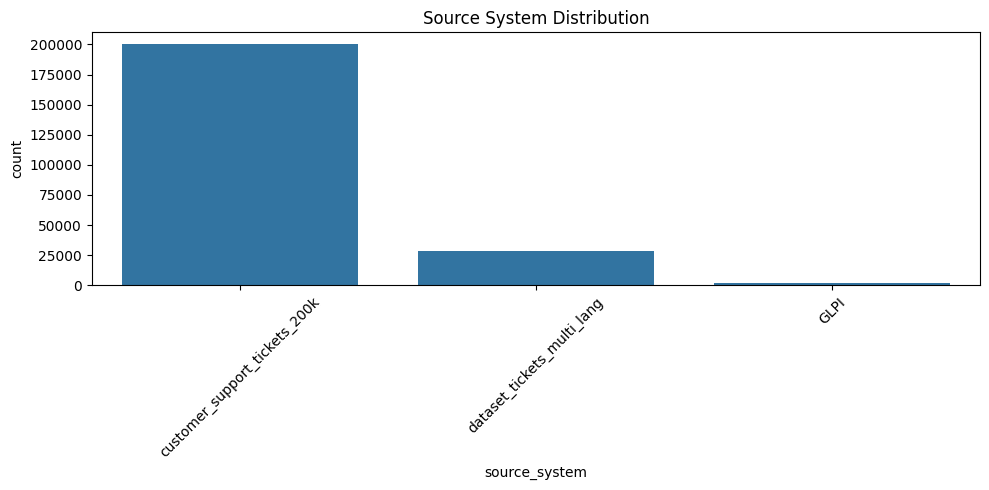

In [33]:
# ============================================================
# CELL 11 — SOURCE SYSTEM DISTRIBUTION
# ============================================================
if "source_system" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x="source_system",
        order=df["source_system"].value_counts().index
    )

    plt.title("Source System Distribution")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [34]:
# ============================================================
# CELL 12 — VISUALIZE SOURCE SYSTEMS
# ============================================================
TEXT_COLUMN = "text_corpus"

if TEXT_COLUMN in df.columns:

    df["text_length"] = (
        df[TEXT_COLUMN]
        .fillna("")
        .astype(str)
        .str.len()
    )

    print("=" * 60)
    print("TEXT LENGTH STATISTICS")
    print("=" * 60)

    print(df["text_length"].describe())

else:
    print(f"{TEXT_COLUMN} column not found.")


TEXT LENGTH STATISTICS
count    230114.000000
mean        168.484473
std         121.733444
min           0.000000
25%         113.000000
50%         137.000000
75%         149.000000
max        1526.000000
Name: text_length, dtype: float64


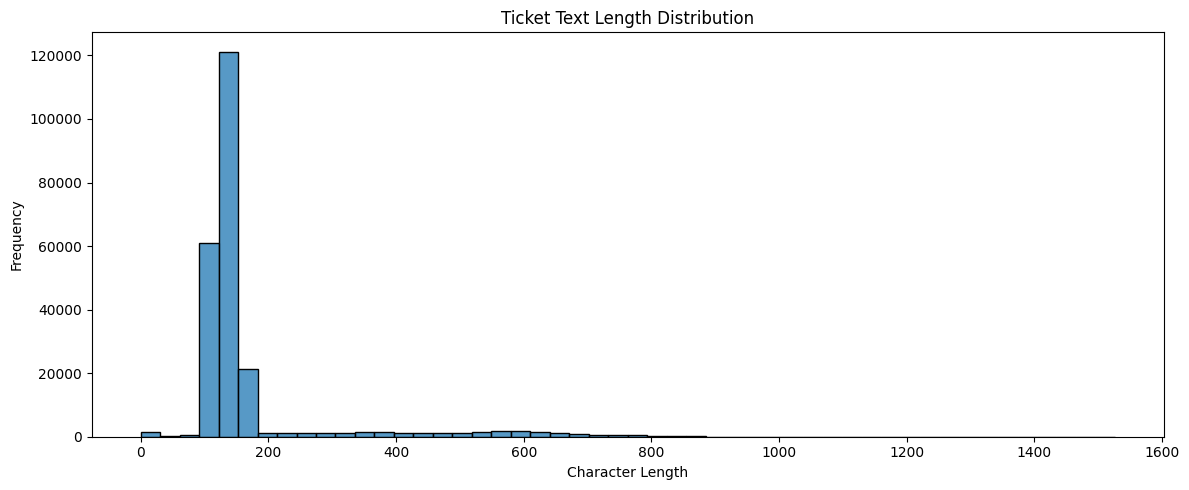

In [35]:
# ============================================================
# CELL 13 — TEXT LENGTH ANALYSIS
# ============================================================

if "text_length" in df.columns:

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df["text_length"],
        bins=50
    )

    plt.title("Ticket Text Length Distribution")
    plt.xlabel("Character Length")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

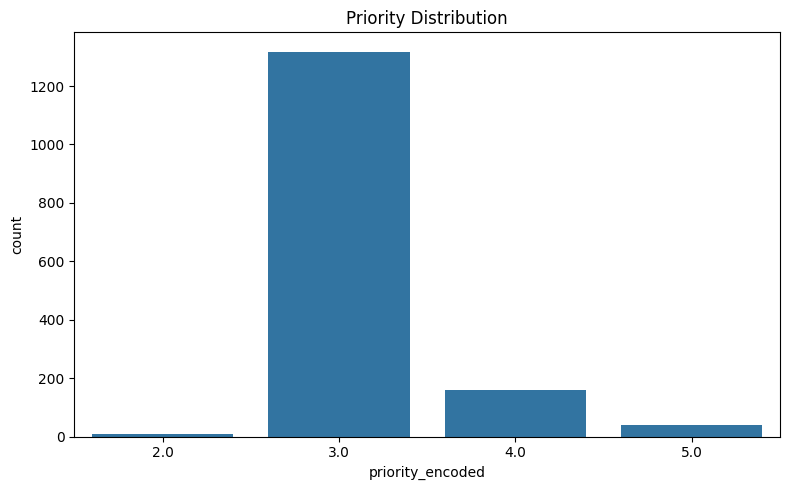

In [36]:
# ============================================================
# CELL 14 — TEXT LENGTH DISTRIBUTION
# ============================================================
if "priority_encoded" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="priority_encoded"
    )

    plt.title("Priority Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("priority_encoded column not found.")

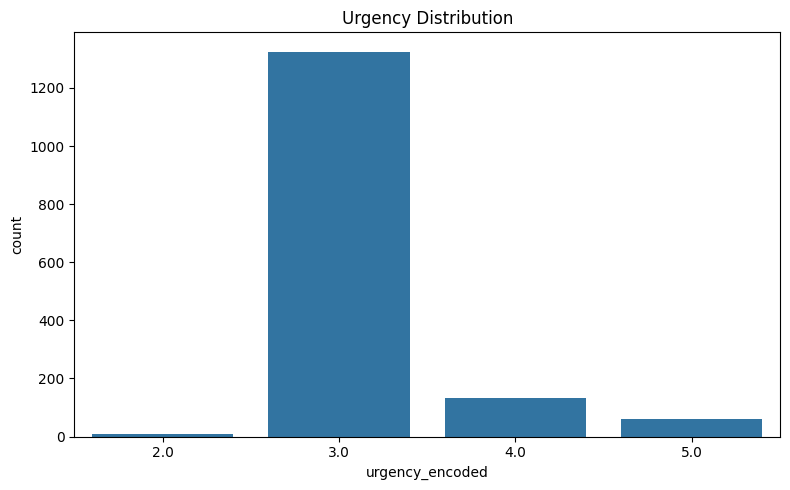

In [ ]:
# ============================================================
# CELL 14 — PRIORITY DISTRIBUTION
# ============================================================
if "priority_encoded" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="priority_encoded"
    )

    plt.title("Priority Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("priority_encoded column not found.")

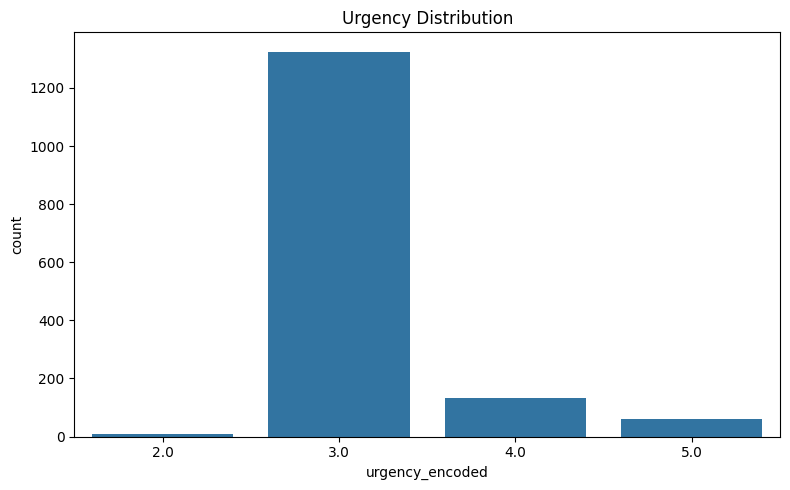

In [38]:
# ============================================================
# CELL 16 — URGENCY DISTRIBUTION
# ============================================================

if "urgency_encoded" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="urgency_encoded"
    )

    plt.title("Urgency Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("urgency_encoded column not found.")

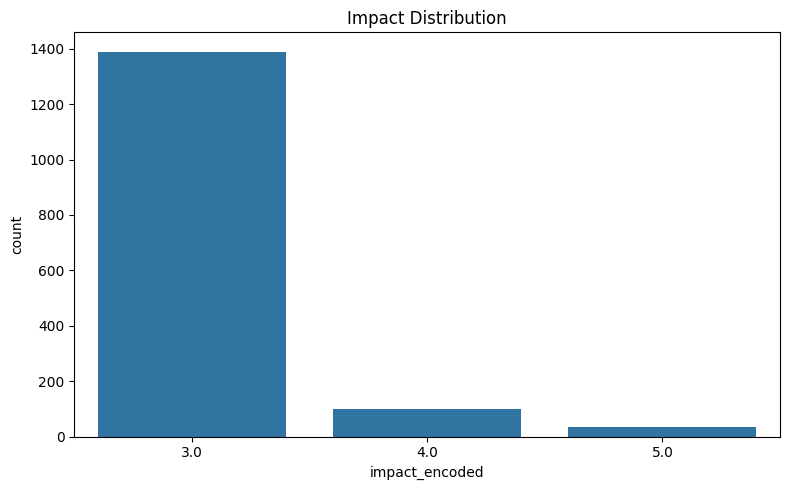

In [39]:
# ============================================================
# CELL 17 — IMPACT DISTRIBUTION
# ============================================================

if "impact_encoded" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="impact_encoded"
    )

    plt.title("Impact Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("impact_encoded column not found.")


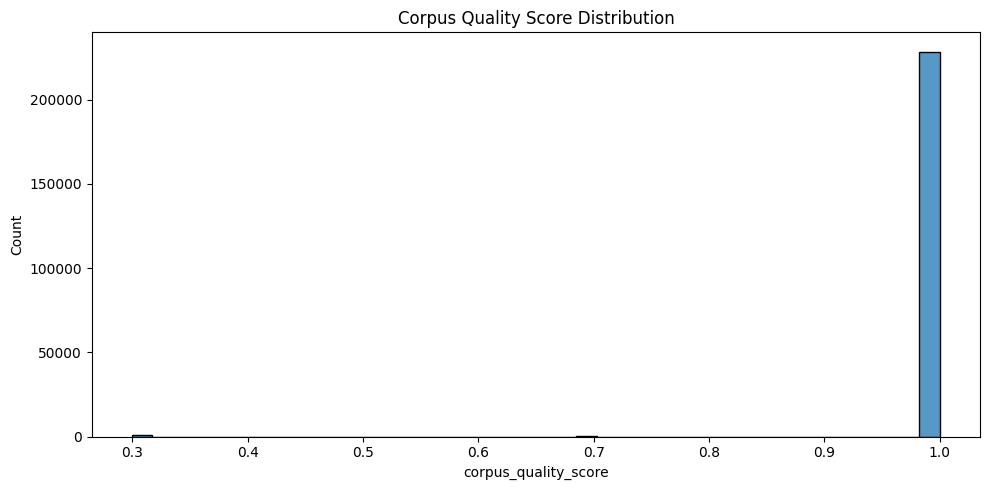

In [40]:
# ============================================================
# CELL 18 — CORPUS QUALITY DISTRIBUTION
# ============================================================

if "corpus_quality_score" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df["corpus_quality_score"].dropna(),
        bins=40
    )

    plt.title("Corpus Quality Score Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("corpus_quality_score column not found.")


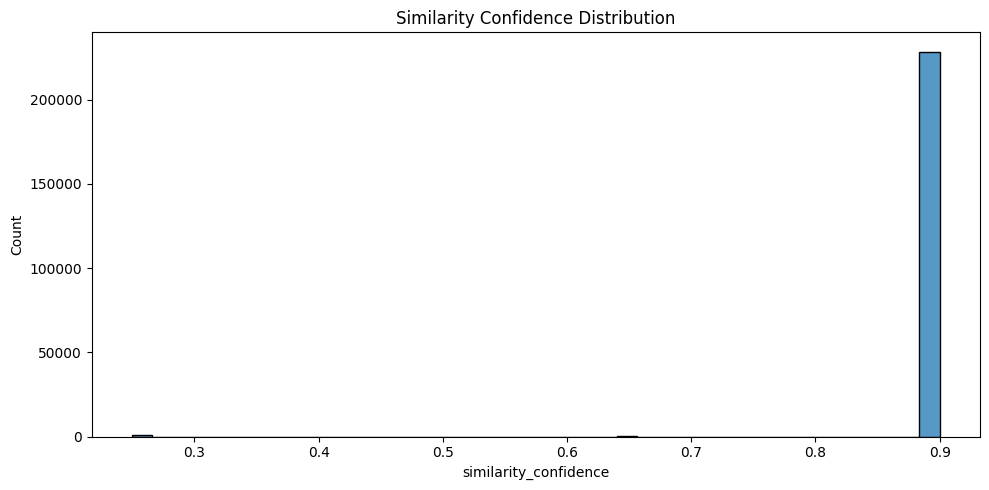

In [41]:
# ============================================================
# CELL 19 — SIMILARITY CONFIDENCE DISTRIBUTION
# ============================================================

if "similarity_confidence" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df["similarity_confidence"].dropna(),
        bins=40
    )

    plt.title("Similarity Confidence Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("similarity_confidence column not found.")

In [42]:
# ============================================================
# CELL 20 — DATASET HEALTH SUMMARY
# ============================================================

print("=" * 60)
print("DATASET HEALTH SUMMARY")
print("=" * 60)

print(f"Rows                    : {len(df):,}")
print(f"Columns                 : {df.shape[1]}")
print(f"Memory Usage            : {memory_mb:.2f} MB")

if "ticket_pk" in df.columns:
    print(f"Duplicate ticket_pk     : {df.duplicated(subset=['ticket_pk']).sum():,}")

if "text_length" in df.columns:
    print(f"Average Text Length     : {df['text_length'].mean():.2f}")
    print(f"Median Text Length      : {df['text_length'].median():.2f}")

print("\nTop Missing Columns:")
display(nulls.head(10))

DATASET HEALTH SUMMARY
Rows                    : 230,114
Columns                 : 30
Memory Usage            : 136.02 MB
Duplicate ticket_pk     : 0
Average Text Length     : 168.48
Median Text Length      : 137.00

Top Missing Columns:


,column,null_count,null_percentage
0,similarity_scores,230114,100.00
1,similar_ticket_ids,230114,100.00
2,urgency_encoded,228587,99.34
3,priority_encoded,228587,99.34
4,synthetic_text_corpus,228587,99.34
5,impact_encoded,228587,99.34
6,followup_count_bucket,228587,99.34
7,closed_at,29203,12.69
8,created_at,28587,12.42
9,embedding_model,1527,0.66


In [43]:
# ============================================================
# CELL 21 — SAVE BASIC REPORT
# ============================================================

report = {
    "rows": len(df),
    "columns": df.shape[1],
    "memory_mb": round(memory_mb, 2),
}

report_df = pd.DataFrame([report])

report_df.to_csv(
    "../evaluation/data_understanding_report.csv",
    index=False
)

print("Basic report exported successfully.")

Basic report exported successfully.
